LSTM은 딥러닝에서 시계역 데이터(시간 흐름 데이터)를 다루는 모델임

#### 이미지 1장을 '모델에 넣을 수 있는 형태'로 바꾸는 코드

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array  #이미지 파일 열기, 이미지를 배열로 변환
import matplotlib.pyplot as plt

In [ ]:
ls /content/nuriho.jpeg # 이미지 위치 확인

ls: cannot access '/content/nuriho.jpeg': No such file or directory


In [ ]:
img = load_img('/content/drive/MyDrive/nuriho.jpeg') # 이미지 파일을 불러와서 img에 저장
# PIL(Image) 객체로 반환 -> 타입이 PIL.Image라 아직 숫자 형태 아님 -> 딥러닝 모델에 바로 넣을 수 없음

In [ ]:
!pwd # 현재 위치 확인하는 명령어

/content


In [ ]:
data = img_to_array(img) # 불러온 이미지를 Numpy 배열로 변환 -> 각 픽셀 값을 숫자로 표현
data.shape #(높이, 너비, 채널) : 각 값 0~255 사이(정규화 전)
# 채널 : 3 -> RGB 컬러 이미지라는 뜻

(640, 640, 3)

In [ ]:
samples = data[np.newaxis, :] # 새로운 차원(axis) 하나 추가 -> 샘플 수(batch_size) 차원 추가함

In [ ]:
samples.shape

(1, 640, 640, 3)



```
samples = data[np.newaxis, :]
```
shape : (640,640,3) -> (1, 640,640,3)  
- np.newaxis : 이 데이터가 이미지 1장짜리 배치다 알려줌  
- 배치 차원 붙이는 이유  
-> 딥러닝 모델 입력 받는 형태 : (batch_size, height, width, channels)   
-> 이미지 1장이어도 '1장짜리 묶음(batch)로 줘야 함



# **위 코드까지의 흐름 요약 **
이미지 파일 불러옴 -> 숫자 배열로 변경 -> 배치 차원 추가 -> 모델 입력 준비 완료

In [ ]:
# 이미지를 이동시키면서 '가짜 학습 이미지를' 자동으로 계속 만들어주는 설정
# 한장짜리 누리호 사진을 여러장으로 데이터 증가 시키기
datagen = ImageDataGenerator(vertical_flip=True, horizontal_flip=True, width_shift_range=[-200,200])

- vertical_flip=True : 이미지 상하 반전
- horizontal_flip=True : 좌우 반전
- width_shift_range=[-200,200] : 좌우 이동  

<데이터 증강 이유>  
한 장의 이미지를 여러장으로 증강시켜 모델이 '외우지 않고 일반화해서 이해하도록 만들기 위해서'  
-> 같은 의미를 가진 다양한 표현을 만들어 줌

In [ ]:
# 이미지 증강이 실제로 시작되는 순간
it = datagen.flow(samples, batch_size=1)




```python
it = datagen.flow(samples, batch_size=1)
```
원본 이미지(sampels)를 이용해서 ImageDataGenerator(datagen)이 증강된 이미지를 배치 단위로 계속 만들어주는 반복기(iterator)를 생성
- datagen : 증강 규칙 들어있음
- flow() : 그 규칙을 실제로 적용하라는 명령
- it : 증강 이미지 자동 생성기
- batch_size=1 : 한번에 이미지 1장씩 생성



In [ ]:
it

In [ ]:
# next() : 하나씩 꺼내주는 상자
batch = next(it)
batch.shape

(1, 640, 640, 3)

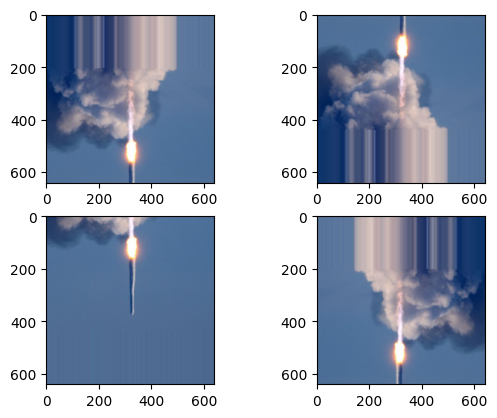

In [ ]:
# 증강된 이미지 4장을 한 화면에 동시에 보여주기 위한 반복문
for i in range(4):
  plt.subplot(2,2,i+1) # 가로2 세로2 -> 한 화면에 4칸
  sub_image = next(it) # it에서 매번 새로운 증강 이미지 하나씩 꺼내오기
  image=sub_image[0].astype('uint8')
  plt.imshow(image)

#### next()함수
-> 반복자(iterator)에서 다음 데이터를 하나(배치 단위로) 꺼내는 함수  
<필요한 이유>   
ImageDataGenerator.flow()는 이미지를 계속 만들어줄 기계라 next()로 호출해서 생성한 이미지를 출력해야 함

In [ ]:
# 증강한 이미지 next()로 꺼내서 sub_image 변수에 저장함
# 증강한 이미지 shape 보기
sub_image.shape

(1, 640, 640, 3)

In [ ]:
# 배치형태로 들어온 데이터에 실제 이미지 1장만 꺼내는 코드
sub_image[0]

array([[[ 89., 117., 154.],
        [ 89., 117., 154.],
        [ 89., 117., 154.],
        ...,
        [ 11.,  50., 105.],
        [ 12.,  51., 106.],
        [ 14.,  53., 108.]],

       [[ 89., 117., 154.],
        [ 89., 117., 154.],
        [ 89., 117., 154.],
        ...,
        [ 11.,  50., 105.],
        [ 12.,  51., 106.],
        [ 14.,  53., 108.]],

       [[ 89., 117., 154.],
        [ 89., 117., 154.],
        [ 89., 117., 154.],
        ...,
        [ 11.,  50., 105.],
        [ 12.,  51., 106.],
        [ 14.,  53., 108.]],

       ...,

       [[ 78., 110., 149.],
        [ 78., 110., 149.],
        [ 77., 109., 148.],
        ...,
        [ 79., 111., 150.],
        [ 80., 112., 151.],
        [ 80., 112., 151.]],

       [[ 79., 111., 150.],
        [ 78., 110., 149.],
        [ 78., 110., 149.],
        ...,
        [ 79., 111., 150.],
        [ 80., 112., 151.],
        [ 80., 112., 151.]],

       [[ 80., 112., 151.],
        [ 79., 111., 150.],
        [ 78., 1

####ResNet50
-> 이미지를 보고 정답 맞히는 데 특화된 딥러닝 모델  

Residual Network(잔차 신경망)  
- 충이 깊은 신경망도 안정적으로 학습 가능  

50의 의미
- CNN 층이 50개  
- 숫자가 클 수록 더 복잡한 특징 봄(계산량 ↑, 느려짐 ↑)

In [ ]:
# 1. 사전 학습된 ResNet50 모델, 전처리 함수, 예측 결과를 사람이 읽이 좋게 바꿔주는 함수 불러오기
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

In [ ]:
# 2. ImageNet 데이터 셋으로 미리 학습된 ResNet50 모델 생성
# weights(가중치) = 'imagenet' : ImageNet(맨 끝이 1000개인)으로 이미 학습된 ResNet50을 가져와 쓰겠다
model = ResNet50(weights='imagenet')

102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 3. 예측에 사용할 이미지 파일 경로
img_path='/content/drive/MyDrive/nuriho.jpeg'

In [ ]:
# 4.
img=load_img(img_path, target_size=(224,224)) # 이미지 파일 불러와서 ResNet50 입력 크기인 224x224로 리사이즈
x = img_to_array(img)  # 이미지 객체를 Numpy 배열로 변환 : shape이 (224,224,3) -> ( 높이, 너비, 채널(RGB))
x = x[np.newaxis, :]  # 맨 앞에 배치 차원 하나 추가 : shape이 (224,224,3) -> (1,224,224,3) # 모델은 항상 '이미지 여러 장' 형태로 입력받기 때문에 한장만 넣어도 (배치크기=1)이라는 차원 만들어줘야 함
x = preprocess_input(x) # ResNet50 전용 전처리 수행 : 이 모델이 이해할 수 있는 형태로 x를 변환

In [ ]:
preds = model.predict(x) # 전처리된 이미지 x를 ResNet50 모델에 넣어 예측 수행
print('Predicted:', decode_predictions(preds, top=3)[0])  # preds에 들어있는 1000개 확률을 사람이 이해할 수 있게 상위 3개 클래스 이름 + 확률로 변환해서 출력

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n04008634', 'projectile', np.float32(0.5033159)), ('n03773504', 'missile', np.float32(0.42003518)), ('n04266014', 'space_shuttle', np.float32(0.0765868))]




```python
print('Predicted:', decode_predictions(preds, top=3)[0])
```
- decode_predictions(preds, top=3)

  -> 1000개 클래스 확률을 사람이 읽을 수 있는 (클래스ID, 클래스이름, 확률) 형태로 바꿔줌  
  -> top=3 → 상위 3개만 뽑음  
  -> np.float32(0.5033159) : 50.33%

- 뒤에 [0]이 붙는 이유  
  -> preds는 배치 단위 출력이라서 (1,1000)임  
  -> decode 결과도 “배치 개수만큼 리스트”로 나오기 때문에 첫 번째(유일한) 이미지 결과만 보려고 [0]을 한 거야.



## 전이학습
: 이미 다른 문제로 '미리 잘 학습된 모델'을 가져와서 내 문제 맞게 재사용 + 약간의 추가학습 하는 방법
1. 본체사용, top -> 변경해서 사용
2. 미세 조정

학습률 조정 0.001?(이게 뭐람)

In [ ]:
ls /content/drive/MyDrive

 1205_딥러닝_day1.ipynb              'Colab Notebooks'/
 1209.ipynb                           data/
 1209_딥러닝_day3.ipynb              'Footwear.zip의 사본'
 1210_day4.ipynb                      Men_resNet50_features.npy
 1211_dayt5.ipynb                     Men_ResNet50_features_product_ids.npy
 251208_복습.ipynb                    nuriho.jpeg
'cats_and_dogs_filtered.zip의 사본'


In [ ]:
# 구글에서 제공하는 '고양이vs개 이미지 데이터셋(zip파일)'을 내 구글 드라이브에 다운로드하는 명령어
# wget : 웹에서 파일 다운로드하는 명령어
!wget --no-check-certificate \
https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip \
-O ./drive/MyDrive/data/tmp/cats_and_dogs_filtered.zip

--2025-12-14 10:10:58--  https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.108.207, 192.178.142.207, 142.251.121.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.108.207|:443... connected.
HTTP request sent, awaiting response... 403 Forbidden
2025-12-14 10:10:58 ERROR 403: Forbidden.



In [ ]:
# 드라이브에 있는 zip 파일 압축 풀기
import os
import zipfile

local_zip = '/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered.zip'

zip_ref = zipfile.ZipFile(local_zip, 'r')  # zip 파일 열어주는 핵심코드

zip_ref.extractall('/content/drive/MyDrive/data/tmp')  # 압축 풀기
zip_ref.close()  # 파일 닫기

BadZipFile: File is not a zip file

In [ ]:
ls /content/drive/MyDrive/data/tmp

cats_and_dogs_filtered/  cats_and_dogs_filtered.zip  Footwear/  Footwear.zip


In [ ]:
# 고양이/개 이미지 데이터셋의 학습용·검증용 폴더 위치를 코드에서 편하게 쓰기 위해 변수로 정리한 것
import os

base_dir = '/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered' # 데이터셋의 기준 폴더

train_dir = os.path.join(base_dir, 'train')  # 학습 데이터 폴더 경로 만들기
validation_dir = os.path.join(base_dir, 'validation')  # 데이터셋 기준 폴더 base_dir 안에서 'validation' 폴더의 전체 경로를 만들어 변수에 저장

os.path.join()  
-> 운영체제에 맞는 경로 자동 처리  
-> 경로 실수 방지

In [ ]:
train_dir

'/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered/train'

In [ ]:
validation_dir

'/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered/validation'

In [ ]:
# 학습용/검증용 데이터 안에서 고양이 폴더, 개 폴더의 정확한 위치를 변수로 정리
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')


In [ ]:
print(train_cats_dir)
print(train_dogs_dir)
print(validation_cats_dir)
print(validation_dogs_dir)

/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered/train/cats
/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered/train/dogs
/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered/validation/cats
/content/drive/MyDrive/data/tmp/cats_and_dogs_filtered/validation/dogs


In [ ]:
# 이미지 읽어서 전처리 후 모델에 공급 준비
# rescale=1./255 : 픽셀 값을 0~1 사이의 실수로 정규화
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

#### ImageDataGenerator 역할  
이미지 읽어서 -> 전처리(필요하면 증강) -> 모델에 공급

In [ ]:
# 폴더에 있는 고양이/개 이미지를 자동으로 읽어서 크기 맞추기, 정규화, 배치로 묶어서
# (이미지 묶음 X, 정답 y) 형태로 계속 꺼내주는 데이터 공급기(generator) 만드는 코드
train_generator = train_datagen.flow_from_directory(
    train_dir,  # 학습 이미지들이 들어있는 폴더 경로
    target_size = (150,150),  # 이미지 150x150으로 리사이즈
    batch_size = 20,  # 한번에 모델에 넣어줄 이미지 개수(배치크기) -> 20장씩 묶어서 반환
    class_mode='binary')  # 정답(y)를 어떤 형태로 만들지 결정, binary : 이진분류

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size = (150,150),
    batch_size = 20,
    class_mode = 'binary')

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Found 2000 images belonging to 2 classes.  
-> 학습 이미지 2000장, 클래스 2개  
Found 1000 images belonging to 2 classes.  
-> 검증 이미지 1000장, 클래스 2개

<숙제> - 월요일 까지  
위에 코드로 모델을 돌릴때  
history = model.fit() 으로 모델 학습시 () 괄호에 들어갈 코드 채우기  
어떤 모델인지는 안말해 주심 -> 모델 구성 어떻게 하든 상관없음

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # 이진 분류
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
# model.fit(학습데이터, epochs(학습 반복 횟수), steps_per_epoch(한 epoch에 generator에서 몇번 batch를 꺼낼지(정수형태로)))
model.fit(train_generator, epochs=10, steps_per_epoch = 2000//20)

Epoch 1/10
 10/100 ━━━━━━━━━━━━━━━━━━━━ 7:54 5s/step - accuracy: 0.5059 - loss: 1.0454

KeyboardInterrupt: 

steps_per_epoch = 한 epoch 동안 batch를 몇번 꺼낼지 => 반드시 정수 형태여야 함  
steps_per_epoch = 2000//20  
= steps_per_epoch = int(2000/20)  
= steps_per_epoch = train_generator.samples // train_generator.batch_size


In [ ]:
# Footwear.zip 파일 압축 해제
import os
import zipfile

local_zip = '/content/drive/MyDrive/data/tmp/Footwear.zip'

zip_ref = zipfile.ZipFile(local_zip, 'r')  # zip 파일 열어주는 핵심코드

zip_ref.extractall('/content/drive/MyDrive/data/tmp')  # 압축 풀기

###unzip 하기


```python
!unzip /content/drive/MyDrive/data/tmp/Footwear.zip
```



In [ ]:
# 압축 풀렸는지 확인
!ls /content/drive/MyDrive/data/tmp/

cats_and_dogs_filtered	cats_and_dogs_filtered.zip  Footwear  Footwear.zip


In [ ]:
#mv Footwear/ ./drive/MyDrive/data/tmp

In [ ]:
ls /content/drive/MyDrive/data/tmp/Footwear/

Men/  Women/


In [ ]:
ls /content/drive/MyDrive/data/tmp/Footwear/Men

Images/


In [ ]:
import pandas as pd

fashion_df = pd.read_csv('/content/drive/MyDrive/data/fashion.csv')

In [ ]:
fashion_df.head()

,ProductId,Gender,Category,SubCategory,ProductType,Colour,Usage,ProductTitle,Image,ImageURL
0,42419,Girls,Apparel,Topwear,Tops,White,Casual,Gini and Jony Girls Knit White Top,42419.jpg,http://assets.myntassets.com/v1/images/style/p...
1,34009,Girls,Apparel,Topwear,Tops,Black,Casual,Gini and Jony Girls Black Top,34009.jpg,http://assets.myntassets.com/v1/images/style/p...
2,40143,Girls,Apparel,Topwear,Tops,Blue,Casual,Gini and Jony Girls Pretty Blossom Blue Top,40143.jpg,http://assets.myntassets.com/v1/images/style/p...
3,23623,Girls,Apparel,Topwear,Tops,Pink,Casual,Doodle Kids Girls Pink I love Shopping Top,23623.jpg,http://assets.myntassets.com/v1/images/style/p...
4,47154,Girls,Apparel,Bottomwear,Capris,Black,Casual,Gini and Jony Girls Black Capris,47154.jpg,http://assets.myntassets.com/v1/images/style/p...


In [ ]:
footwear_men = fashion_df[fashion_df['Gender']=='Men']

In [ ]:
footwear_men.head()

,ProductId,Gender,Category,SubCategory,ProductType,Colour,Usage,ProductTitle,Image,ImageURL
1326,9204,Men,Footwear,Shoes,Casual Shoes,Black,Casual,Puma Men Future Cat Remix SF Black Casual Shoes,9204.jpg,http://assets.myntassets.com/v1/images/style/p...
1327,18653,Men,Footwear,Flip Flops,Flip Flops,Black,Casual,Fila Men Cush Flex Black Slippers,18653.jpg,http://assets.myntassets.com/v1/images/style/p...
1328,12967,Men,Footwear,Sandal,Sandals,Black,Casual,ADIDAS Men Spry M Black Sandals,12967.jpg,http://assets.myntassets.com/v1/images/style/p...
1329,9036,Men,Footwear,Shoes,Formal Shoes,Black,Formal,Buckaroo Men Flores Black Formal Shoes,9036.jpg,http://assets.myntassets.com/v1/images/style/p...
1330,39988,Men,Footwear,Shoes,Casual Shoes,White,Casual,Gas Men Europa White Shoes,39988.jpg,http://assets.myntassets.com/v1/images/style/p...


In [ ]:
footwear_men.info()

<class 'pandas.core.frame.DataFrame'>
Index: 811 entries, 1326 to 2136
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ProductId     811 non-null    int64 
 1   Gender        811 non-null    object
 2   Category      811 non-null    object
 3   SubCategory   811 non-null    object
 4   ProductType   811 non-null    object
 5   Colour        811 non-null    object
 6   Usage         811 non-null    object
 7   ProductTitle  811 non-null    object
 8   Image         811 non-null    object
 9   ImageURL      811 non-null    object
dtypes: int64(1), object(9)
memory usage: 69.7+ KB


In [ ]:
img_width, img_height = 224, 224  #학습에 사용할 이미지 가로, 세로 크기
train_data_dir = '/content/drive/MyDrive/data/tmp/Footwear/Men/Images' # 학습 이미지들이 들어있는 폴더 경로

nb_train_samples = 811 # 학습에 사용할 전체 이미지 개수
epochs = 50  #전체 학습 데이터를 몇번 반복해서 볼지 -> 811 이미지를 50번 학습하겠다
batch_size=1  # 한번에 모델에 넣는 이미지 개수 : 1장씩 학습

In [ ]:
ls /content/drive/MyDrive/data/tmp/Footwear/Men/Images/images_with_product_ids/

10037.jpg  16163.jpg  22841.jpg  30260.jpg  38654.jpg  44544.jpg  5654.jpg
10039.jpg  16164.jpg  22846.jpg  30261.jpg  38655.jpg  44545.jpg  5665.jpg
10097.jpg  16165.jpg  22958.jpg  3150.jpg   38662.jpg  44572.jpg  5690.jpg
10174.jpg  1636.jpg   22959.jpg  3151.jpg   38663.jpg  44573.jpg  5691.jpg
10180.jpg  1637.jpg   23246.jpg  3159.jpg   38664.jpg  44712.jpg  5696.jpg
10266.jpg  1653.jpg   23247.jpg  3160.jpg   38665.jpg  44713.jpg  5697.jpg
10267.jpg  1654.jpg   23248.jpg  3161.jpg   39263.jpg  44714.jpg  5698.jpg
10268.jpg  16732.jpg  23249.jpg  3168.jpg   39264.jpg  44715.jpg  5699.jpg
10293.jpg  16733.jpg  23489.jpg  31693.jpg  39297.jpg  44740.jpg  57475.jpg
10294.jpg  16734.jpg  23500.jpg  31946.jpg  39310.jpg  44741.jpg  57481.jpg
10295.jpg  16735.jpg  23676.jpg  31947.jpg  39311.jpg  44746.jpg  57500.jpg
10632.jpg  16966.jpg  23677.jpg  31948.jpg  39342.jpg  44747.jpg  57501.jpg
10633.jpg  16969.jpg  23679.jpg  31949.jpg  39546.jpg  44748.jpg  57506.jpg
10634.jpg  17026.jpg

In [ ]:
datagen = ImageDataGenerator(rescale=1. / 255)
generator = datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode=None,
    shuffle=False)

Found 811 images belonging to 1 classes.


In [ ]:
Itemcodes = []

for i in generator.filenames : # i는 파일 이름
  Itemcodes.append(i[(i.find("/")+1): i.find(".")])

In [ ]:
i

'images_with_product_ids/9497.jpg'

In [ ]:
i.find("/") # i 파일명에서 '/'의 위치 인덱스 출력

23

In [ ]:
Itemcodes

['10037',
 '10039',
 '10097',
 '10174',
 '10180',
 '10266',
 '10267',
 '10268',
 '10293',
 '10294',
 '10295',
 '10632',
 '10633',
 '10634',
 '10635',
 '11851',
 '11856',
 '11912',
 '11913',
 '11914',
 '11915',
 '11922',
 '11923',
 '11924',
 '11940',
 '11941',
 '11946',
 '11947',
 '11948',
 '11949',
 '11971',
 '11976',
 '11977',
 '11978',
 '11979',
 '11983',
 '11985',
 '12506',
 '12507',
 '12508',
 '12509',
 '12704',
 '12705',
 '12876',
 '12882',
 '12885',
 '12903',
 '12904',
 '12956',
 '12957',
 '12958',
 '12959',
 '12960',
 '12961',
 '12966',
 '12967',
 '12968',
 '12969',
 '13072',
 '13073',
 '13074',
 '13075',
 '13080',
 '13081',
 '13198',
 '13214',
 '13215',
 '13359',
 '13537',
 '13646',
 '13648',
 '13649',
 '13676',
 '13677',
 '13679',
 '13683',
 '13684',
 '13685',
 '14490',
 '14491',
 '14496',
 '14497',
 '14498',
 '14499',
 '15062',
 '15250',
 '15313',
 '15314',
 '15315',
 '15376',
 '15377',
 '15378',
 '15379',
 '15382',
 '15384',
 '15385',
 '15406',
 '15510',
 '15516',
 '15517',


In [ ]:
i[(i.find("/")+1): i.find(".")]

'9497'

In [ ]:
model = ResNet50(include_top=False, weights='imagenet')
ex_features = model.predict(generator, nb_train_samples // batch_size)

NameError: name 'generator' is not defined

In [ ]:
ex_features.shape



```
(811, 7, 7, 2048)
 ↑    ↑  ↑   ↑
개수   세로 가로  특징 수
```



In [ ]:
# 딥러닝에서 특징(feature) 배열의 모양(shape)을 바꾸는 코드
ext_features = ex_features.reshape((811, 100352))
# ext_features : CNN 같은 모델에서 이미지에서 뽑아낸 '특징 벡터들'이 여러개 모여있는 배열
# ex) 이미지 811장, 각 이미지마자 CNN이 뽑아낸 특징 100352개
# reshape((811, 100352)) : CNN이 뽑은 특징 데이터를 811개 샘플 x 100,352차원 벡터 형태로 평탄화

ext_features.shape

(811, 100352)



```
ex_features_reshaped = ex_features.reshape(811, 7*7*2048)
```

-> (811, 100352)

In [ ]:
# 모델이 뽑아낸 특징(feature)과 그에 대응되는 상품 ID를 .npy 파일로 저장하는 코드
np.save(open('./Men_resNet50_features.npy', 'wb'), ext_features)  # 'wb' : write binary(이진 파일)
np.save(open('./Men_ResNet50_features_product_ids.npy', 'wb'), np.array(Itemcodes))

Men_resNet50_features.npy 파일에
모든 이미지의 ResNet50 특징 정보를 저장한다  

각 feature가 어떤 상품에 해당하는지 알 수 있도록
상품 ID 목록을 별도의 파일로 저장

In [ ]:
ls

drive/                     Men_ResNet50_features_product_ids.npy  sample_data/
Men_resNet50_features.npy  nuriho.jpeg


In [ ]:
cp *.npy ./drive/MyDrive/

In [ ]:
import numpy as np
from sklearn.metrics import pairwise_distances

X = np.array([[0,0], [1,1], [2,2]])

In [ ]:
D = pairwise_distances(X, np.array([[3,4]]), metric = 'euclidean')

In [ ]:
D

array([[5.        ],
       [3.60555128],
       [2.23606798]])

In [ ]:
ProductId = Itemcodes

In [ ]:
product_id = '39972'

In [ ]:
doc_id = ProductId.index(product_id)

In [ ]:
doc_id

488

In [ ]:
distance = pairwise_distances(ext_features, ext_features[doc_id].reshape(1, -1))

In [ ]:
np.array([[1,2,3,4]]).shape

(1, 4)

In [ ]:
distance[:3]

array([[41.427555],
       [38.029835],
       [37.43151 ]], dtype=float32)

In [ ]:
np.argsort(distance.flatten())[0:3]

array([488, 619, 173])

In [ ]:
np.sort(distance.flatten())[0:3]

array([1.1444092e-05, 2.1595800e+01, 2.1953775e+01], dtype=float32)

In [ ]:
indices = np.argsort(distance.flatten())[0:3]

In [ ]:
indices

array([488, 619, 173])

In [ ]:
fashion_df[['ImageURL', 'ProductTitle']].head()

,ImageURL,ProductTitle
0,http://assets.myntassets.com/v1/images/style/p...,Gini and Jony Girls Knit White Top
1,http://assets.myntassets.com/v1/images/style/p...,Gini and Jony Girls Black Top
2,http://assets.myntassets.com/v1/images/style/p...,Gini and Jony Girls Pretty Blossom Blue Top
3,http://assets.myntassets.com/v1/images/style/p...,Doodle Kids Girls Pink I love Shopping Top
4,http://assets.myntassets.com/v1/images/style/p...,Gini and Jony Girls Black Capris


In [ ]:
indices[0]

np.int64(488)

In [ ]:
ProductId[indices[0]]

'39972'

In [ ]:
ip_row = fashion_df[['ImageURL','ProductTitle']].loc[fashion_df['ProductId'] == int(ProductId[indices[0]])]

In [ ]:
ip_row

,ImageURL,ProductTitle
1451,http://assets.myntassets.com/v1/images/style/p...,GAS Men Grey Campus Casual Shoes


In [ ]:
from PIL import Image
from PIL import ImageFile
import urllib.request

In [ ]:
for idx, row in ip_row.iterrows():
  print(idx)
  print('=========='*50)
  print(row)

1451
ImageURL        http://assets.myntassets.com/v1/images/style/p...
ProductTitle                     GAS Men Grey Campus Casual Shoes
Name: 1451, dtype: object


GAS Men Grey Campus Casual Shoes


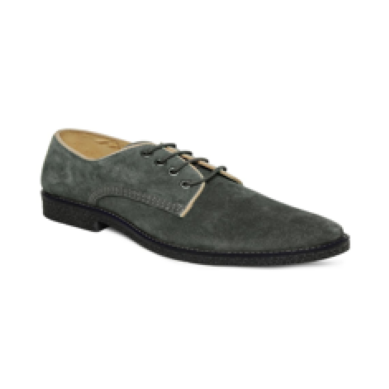

In [ ]:
for idx, row in ip_row.iterrows():
  image = Image.open(urllib.request.urlopen(row['ImageURL']))
  image = image.resize((224,224))
  print(row['ProductTitle'])
  plt.imshow(image)
  plt.axis('off')

Arrow Men Brown Formal Shoes


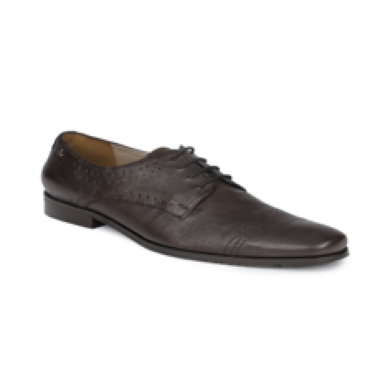

In [ ]:
ip_row2 = fashion_df[['ImageURL','ProductTitle']].loc[fashion_df['ProductId'] == int(ProductId[indices[1]])]

for idx, row in ip_row2.iterrows():
  image = Image.open(urllib.request.urlopen(row['ImageURL']))
  image = image.resize((224,224))
  print(row['ProductTitle'])
  plt.imshow(image)
  plt.axis('off')

Redtape Men Brown Formal Shoes


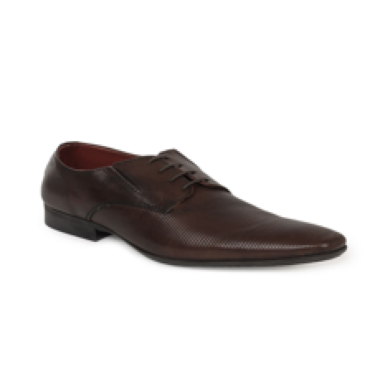

In [ ]:
ip_row3 = fashion_df[['ImageURL','ProductTitle']].loc[fashion_df['ProductId'] == int(ProductId[indices[2]])]

for idx, row in ip_row3.iterrows():
  image = Image.open(urllib.request.urlopen(row['ImageURL']))
  image = image.resize((224,224))
  print(row['ProductTitle'])
  plt.imshow(image)
  plt.axis('off')